In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

import os

pd.set_option('display.max_columns', None)

In [166]:
apartments_2023_08 = pd.read_csv('../data/raw/apartments_pl_2023_08.csv').assign(date='08.2023')
apartments_2023_09 = pd.read_csv('../data/raw/apartments_pl_2023_09.csv').assign(date='09.2023')
apartments_2023_10 = pd.read_csv('../data/raw/apartments_pl_2023_10.csv').assign(date='10.2023')
apartments_2023_11 = pd.read_csv('../data/raw/apartments_pl_2023_11.csv').assign(date='11.2023')
apartments_2023_12 = pd.read_csv('../data/raw/apartments_pl_2023_12.csv').assign(date='12.2023')

apartments_2024_01 = pd.read_csv('../data/raw/apartments_pl_2024_01.csv').assign(date='01.2024')
apartments_2024_02 = pd.read_csv('../data/raw/apartments_pl_2024_02.csv').assign(date='02.2024')
apartments_2024_03 = pd.read_csv('../data/raw/apartments_pl_2024_03.csv').assign(date='03.2024')
apartments_2024_04 = pd.read_csv('../data/raw/apartments_pl_2024_04.csv').assign(date='04.2024')
apartments_2024_05 = pd.read_csv('../data/raw/apartments_pl_2024_05.csv').assign(date='05.2024')
apartments_2024_06 = pd.read_csv('../data/raw/apartments_pl_2024_06.csv').assign(date='06.2024')


In [167]:
df = pd.concat([apartments_2023_08,apartments_2023_09,apartments_2023_10,apartments_2023_11, apartments_2023_12, apartments_2024_01,apartments_2024_02,apartments_2024_03,apartments_2024_04,apartments_2024_05,apartments_2024_06])

df.head()

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,date
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,6.53,9.0,0.118,1.389,0.628,0.105,1.652,NaN,0.413,condominium,concreteSlab,NaN,yes,yes,yes,no,yes,415000,08.2023
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,53.442692,14.559690,2.15,16.0,0.273,0.492,0.652,0.291,0.348,1.404,0.205,cooperative,concreteSlab,NaN,no,yes,yes,no,yes,395995,08.2023
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,53.452222,14.553333,3.24,9.0,0.275,0.672,0.367,0.246,0.300,1.857,0.280,condominium,brick,NaN,no,no,no,no,no,565000,08.2023
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,53.435100,14.532900,2.27,32.0,0.175,0.259,0.223,0.359,0.101,0.310,0.087,condominium,brick,NaN,yes,yes,no,no,yes,640000,08.2023
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,53.410278,14.503611,4.07,1.0,0.218,1.690,0.504,0.704,0.501,2.138,0.514,condominium,NaN,NaN,no,no,no,no,no,759000,08.2023


In [168]:
df = df[(df['city'] == 'warszawa')].copy() #at first we are focusing on Warsaw
df.drop(columns=['city', 'id'], inplace = True)
df.reset_index(drop=True, inplace=True)

df.head()

,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,date
0,apartmentBuilding,112.80,4.0,2.0,5.0,1998.0,52.236141,20.987732,1.19,73.0,0.094,0.445,0.466,0.344,0.070,0.784,0.178,cooperative,brick,premium,yes,yes,yes,no,no,2050000,08.2023
1,blockOfFlats,54.64,2.0,4.0,5.0,1999.0,52.185400,20.959800,5.95,10.0,0.215,1.931,0.940,0.932,0.067,3.064,1.016,condominium,brick,NaN,no,no,yes,no,no,869000,08.2023
2,blockOfFlats,60.00,3.0,NaN,5.0,2007.0,52.260800,21.058970,4.97,16.0,0.205,0.285,0.769,0.219,0.787,0.366,0.254,condominium,NaN,premium,no,yes,yes,no,no,700000,08.2023
3,blockOfFlats,28.80,2.0,9.0,11.0,1978.0,52.238200,20.908600,6.51,19.0,0.324,0.301,0.372,0.275,0.211,2.321,0.201,condominium,concreteSlab,NaN,yes,yes,yes,no,yes,435000,08.2023
4,apartmentBuilding,122.70,5.0,3.0,3.0,1998.0,52.168100,21.079000,8.74,12.0,0.449,1.721,0.311,0.195,0.484,2.651,0.197,condominium,brick,NaN,yes,yes,no,yes,no,1500000,08.2023


## Data Cleaning

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59246 entries, 0 to 59245
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  44412 non-null  object 
 1   squareMeters          59246 non-null  float64
 2   rooms                 59246 non-null  float64
 3   floor                 50210 non-null  float64
 4   floorCount            58673 non-null  float64
 5   buildYear             53648 non-null  float64
 6   latitude              59246 non-null  float64
 7   longitude             59246 non-null  float64
 8   centreDistance        59246 non-null  float64
 9   poiCount              59246 non-null  float64
 10  schoolDistance        59242 non-null  float64
 11  clinicDistance        58977 non-null  float64
 12  postOfficeDistance    59203 non-null  float64
 13  kindergartenDistance  59202 non-null  float64
 14  restaurantDistance    59031 non-null  float64
 15  collegeDistance    

In [170]:
df.describe()

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price
count,59246.000000,59246.000000,50210.000000,58673.000000,53648.000000,59246.000000,59246.000000,59246.000000,59246.000000,59242.000000,58977.000000,59203.000000,59202.000000,59031.000000,57874.000000,59161.000000,5.924600e+04
mean,59.775264,2.687169,3.758952,6.199717,1989.002479,52.227829,21.008215,6.025616,22.529116,0.354674,0.828132,0.482847,0.272050,0.247822,1.545239,0.303056,1.023081e+06
std,22.658961,0.926591,2.919930,3.741757,28.583806,0.047292,0.063295,3.196114,21.960924,0.270334,0.850803,0.327786,0.208623,0.230125,1.160317,0.267990,4.547033e+05
min,25.000000,1.000000,1.000000,1.000000,1851.000000,52.104600,20.823898,0.020000,0.000000,0.004000,0.001000,0.001000,0.001000,0.001000,0.009000,0.001000,3.000000e+05
25%,43.870000,2.000000,2.000000,4.000000,1969.000000,52.194212,20.961720,3.680000,9.000000,0.176000,0.276000,0.255000,0.137000,0.097000,0.617000,0.136000,7.115538e+05
50%,55.100000,3.000000,3.000000,5.000000,1999.000000,52.229676,21.010930,5.850000,16.000000,0.285000,0.522000,0.417000,0.231000,0.185000,1.162000,0.230000,8.850000e+05
75%,70.100000,3.000000,5.000000,8.000000,2014.000000,52.253500,21.051727,8.050000,28.000000,0.445000,0.973000,0.630000,0.354000,0.321000,2.187000,0.386000,1.200000e+06
max,150.000000,6.000000,29.000000,29.000000,2024.000000,52.363708,21.249710,16.940000,136.000000,2.484000,4.999000,3.524000,2.271000,2.050000,5.000000,3.179000,3.250000e+06


In [171]:
df.isna().sum()

type                    14834
squareMeters                0
rooms                       0
floor                    9036
floorCount                573
buildYear                5598
latitude                    0
longitude                   0
centreDistance              0
poiCount                    0
schoolDistance              4
clinicDistance            269
postOfficeDistance         43
kindergartenDistance       44
restaurantDistance        215
collegeDistance          1372
pharmacyDistance           85
ownership                   0
buildingMaterial        24940
condition               45169
hasParkingSpace             0
hasBalcony                  0
hasElevator              2394
hasSecurity                 0
hasStorageRoom              0
price                       0
date                        0
dtype: int64

In [172]:
categorical_columns = [col for col in df.columns if df[col].dtype == 'object']

for col in categorical_columns:
    print(col)
    print(df[col].unique())

type
['apartmentBuilding' 'blockOfFlats' nan 'tenement']
ownership
['cooperative' 'condominium']
buildingMaterial
['brick' nan 'concreteSlab']
condition
['premium' nan 'low']
hasParkingSpace
['yes' 'no']
hasBalcony
['yes' 'no']
hasElevator
['yes' 'no' nan]
hasSecurity
['no' 'yes']
hasStorageRoom
['no' 'yes']
date
['08.2023' '09.2023' '10.2023' '11.2023' '12.2023' '01.2024' '02.2024'
 '03.2024' '04.2024' '05.2024' '06.2024']


In [173]:
df['type'] = df['type'].fillna('unknown')

le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,date
0,0,112.80,4.0,2.0,5.0,1998.0,52.236141,20.987732,1.19,73.0,0.094,0.445,0.466,0.344,0.070,0.784,0.178,1,0,1,1,1,1,0,0,2050000,6
1,1,54.64,2.0,4.0,5.0,1999.0,52.185400,20.959800,5.95,10.0,0.215,1.931,0.940,0.932,0.067,3.064,1.016,0,0,2,0,0,1,0,0,869000,6
2,1,60.00,3.0,NaN,5.0,2007.0,52.260800,21.058970,4.97,16.0,0.205,0.285,0.769,0.219,0.787,0.366,0.254,0,2,1,0,1,1,0,0,700000,6
3,1,28.80,2.0,9.0,11.0,1978.0,52.238200,20.908600,6.51,19.0,0.324,0.301,0.372,0.275,0.211,2.321,0.201,0,1,2,1,1,1,0,1,435000,6
4,0,122.70,5.0,3.0,3.0,1998.0,52.168100,21.079000,8.74,12.0,0.449,1.721,0.311,0.195,0.484,2.651,0.197,0,0,2,1,1,0,1,0,1500000,6


## EDA

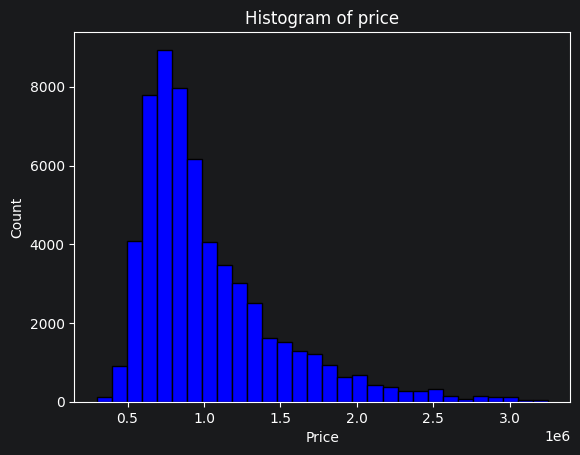

In [174]:
plt.hist(df["price"], bins=30, color="blue", edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Histogram of price")

plt.show()

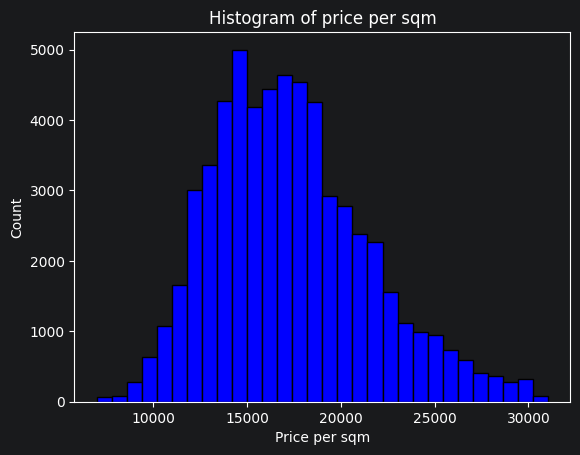

In [175]:
df['pricePerSqm'] = df['price'] / df['squareMeters']

plt.hist(df['pricePerSqm'], bins=30, color="blue", edgecolor="black")
plt.xlabel("Price per sqm")
plt.ylabel("Count")
plt.title("Histogram of price per sqm")
plt.show()

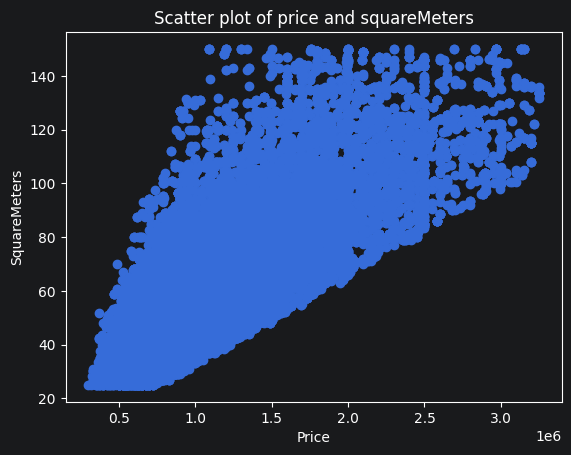

In [176]:
plt.scatter(df['price'], df['squareMeters'])
plt.xlabel("Price")
plt.ylabel("SquareMeters")
plt.title("Scatter plot of price and squareMeters")

plt.show()

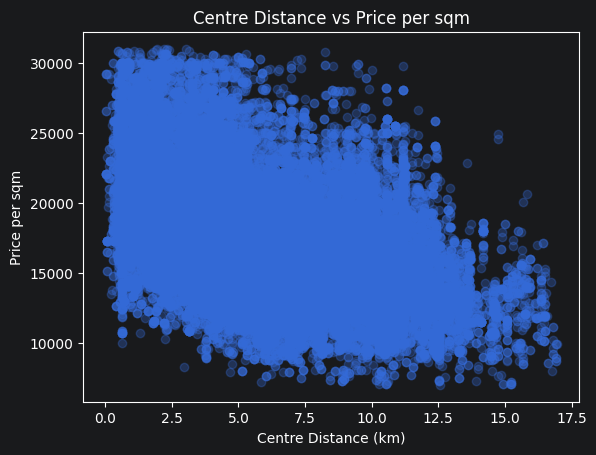

In [177]:
plt.scatter(df['centreDistance'], df['pricePerSqm'], alpha=0.3)
plt.xlabel("Centre Distance (km)")
plt.ylabel("Price per sqm")
plt.title("Centre Distance vs Price per sqm")
plt.show()

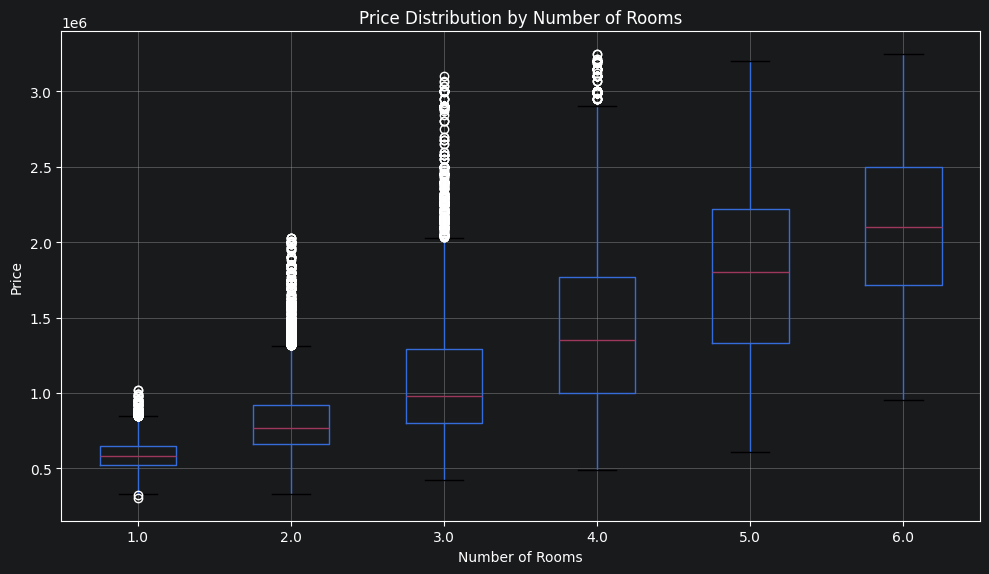

In [178]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='price', by='rooms', ax=ax)
ax.set_title('Price Distribution by Number of Rooms')
ax.set_xlabel('Number of Rooms')
ax.set_ylabel('Price')
plt.suptitle('')
plt.tight_layout()

plt.show()

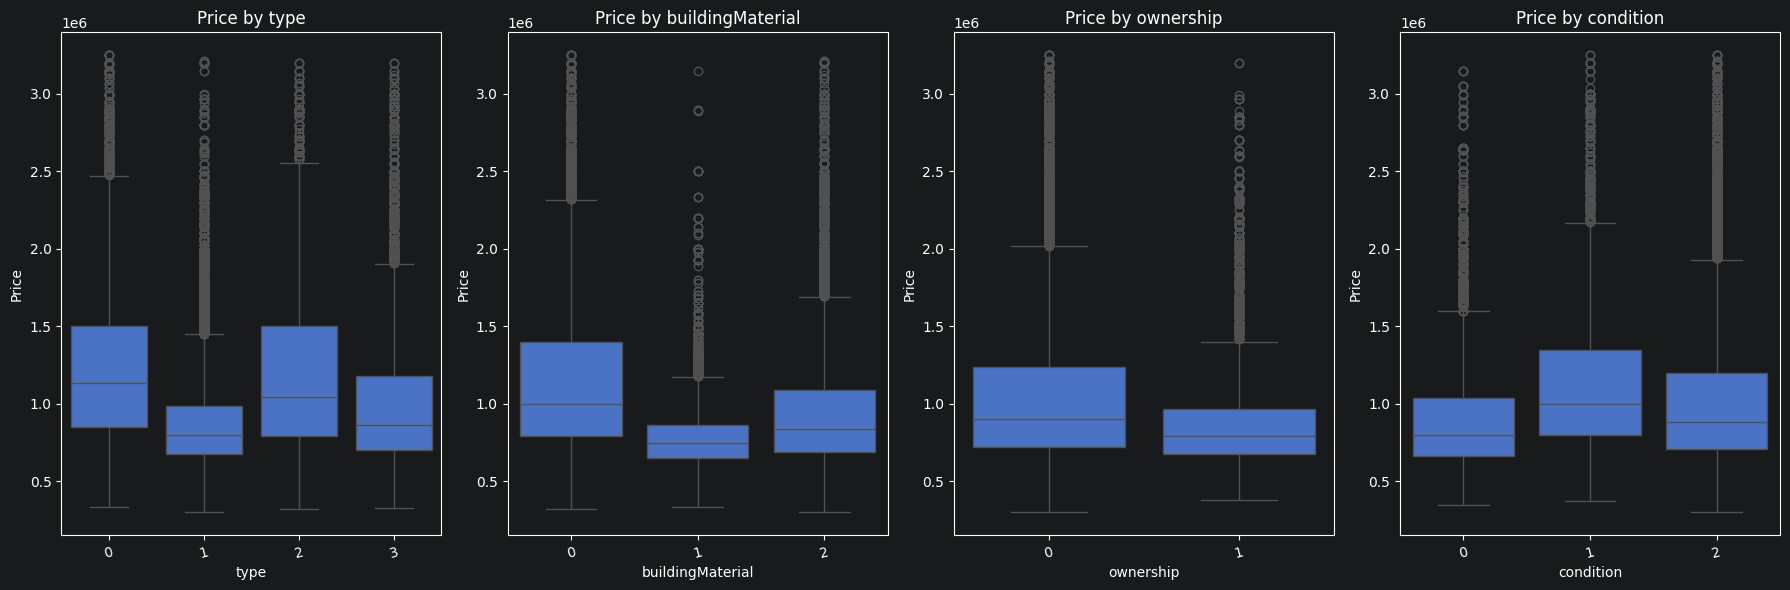

In [179]:
cat_cols_to_plot = ['type', 'buildingMaterial', 'ownership', 'condition']
fig, axes = plt.subplots(1, len(cat_cols_to_plot), figsize=(18, 6))

for i, col in enumerate(cat_cols_to_plot):
    sns.boxplot(x=df[col], y=df['price'], ax=axes[i])
    axes[i].set_title(f'Price by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

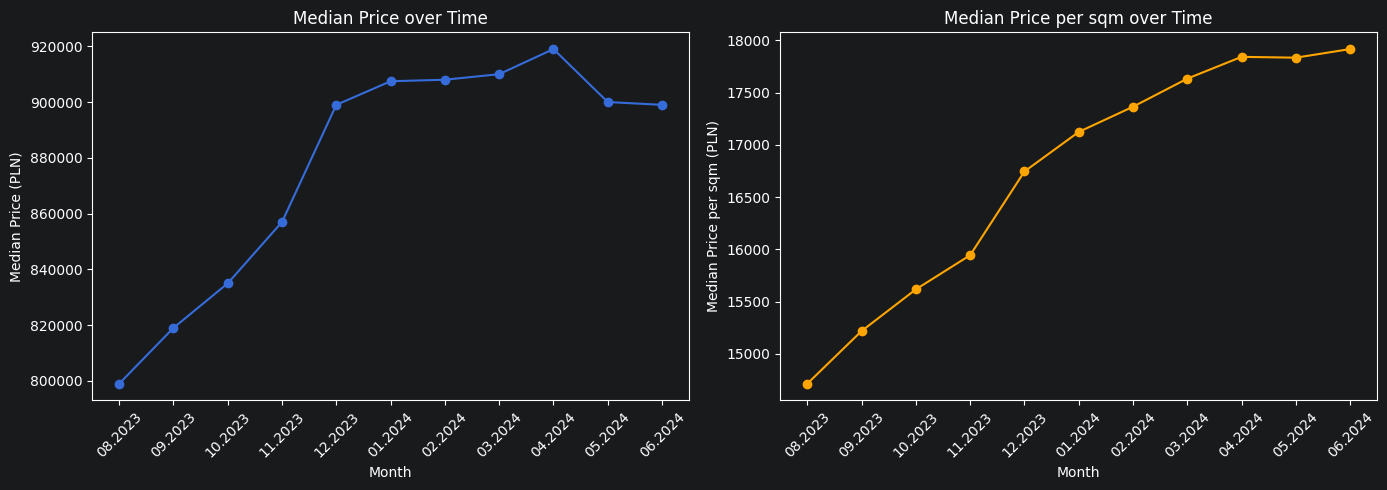

In [180]:
date_mapping = {6: '08.2023', 7: '09.2023', 8: '10.2023', 9: '11.2023', 10: '12.2023',
                0: '01.2024', 1: '02.2024', 2: '03.2024', 3: '04.2024', 4: '05.2024', 5: '06.2024'}
chronological = [6, 7, 8, 9, 10, 0, 1, 2, 3, 4, 5]
date_labels = [date_mapping[i] for i in chronological]

monthly = df.groupby('date')[['price', 'pricePerSqm']].median().reindex(chronological)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(date_labels, monthly['price'], marker='o')
axes[0].set_title('Median Price over Time')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Median Price (PLN)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(date_labels, monthly['pricePerSqm'], marker='o', color='orange')
axes[1].set_title('Median Price per sqm over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Median Price per sqm (PLN)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [181]:
cor_matrix = df.corr()
correlations_with_price = cor_matrix['price'].abs().sort_values(ascending=False)
print(correlations_with_price)

price                   1.000000
squareMeters            0.798859
rooms                   0.619000
pricePerSqm             0.444810
buildingMaterial        0.223848
latitude                0.219648
poiCount                0.176176
centreDistance          0.162967
hasParkingSpace         0.149298
restaurantDistance      0.138753
clinicDistance          0.119642
hasStorageRoom          0.114824
collegeDistance         0.101749
ownership               0.099496
hasSecurity             0.086439
type                    0.078538
date                    0.075171
buildYear               0.068564
longitude               0.062580
hasBalcony              0.059909
floorCount              0.057905
hasElevator             0.052615
postOfficeDistance      0.046345
pharmacyDistance        0.042819
floor                   0.024143
condition               0.017721
kindergartenDistance    0.008988
schoolDistance          0.001620
Name: price, dtype: float64


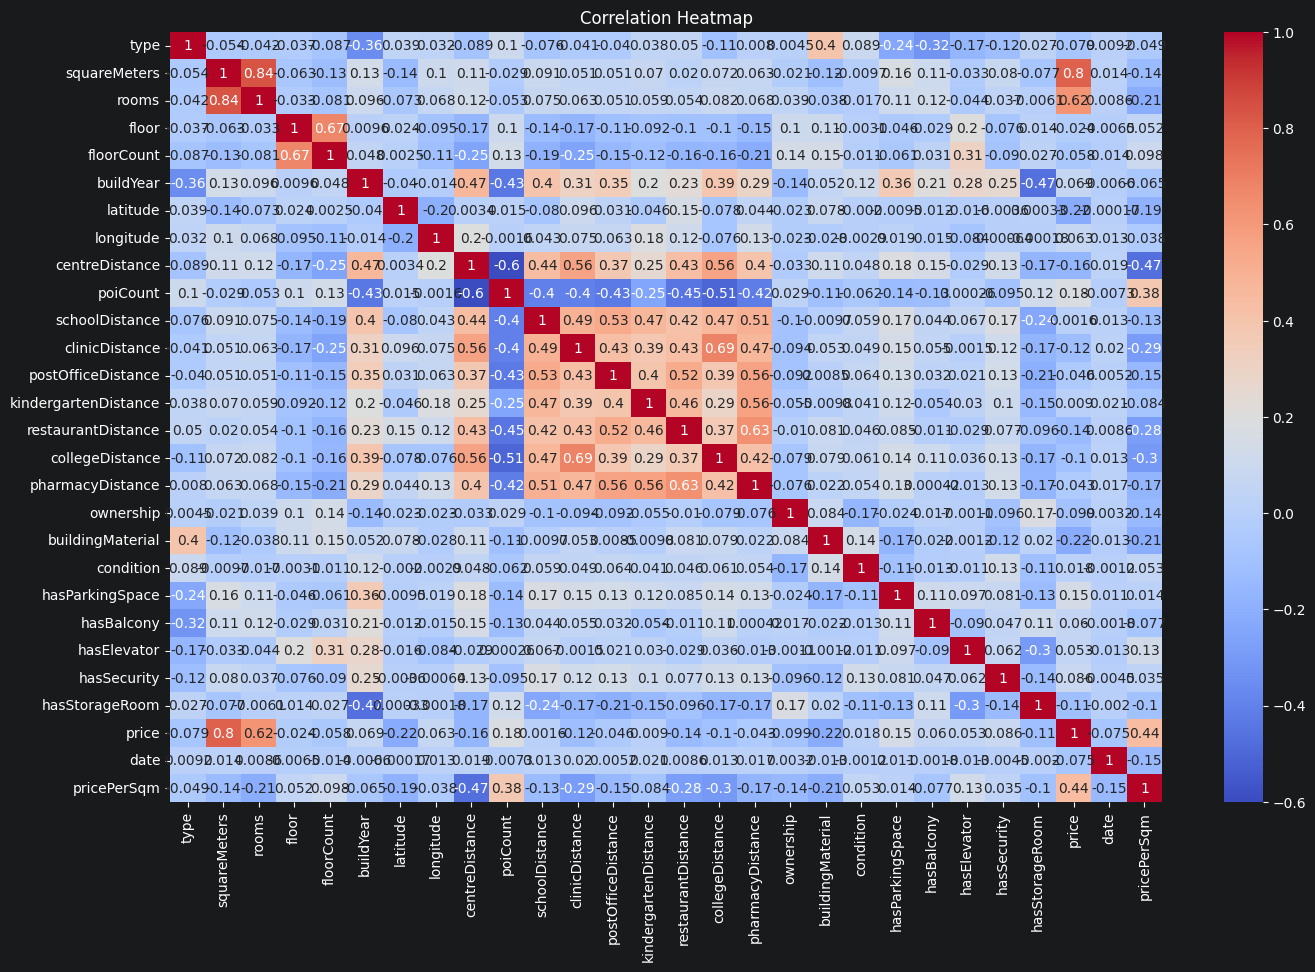

In [182]:
plt.figure(figsize=(16, 10))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

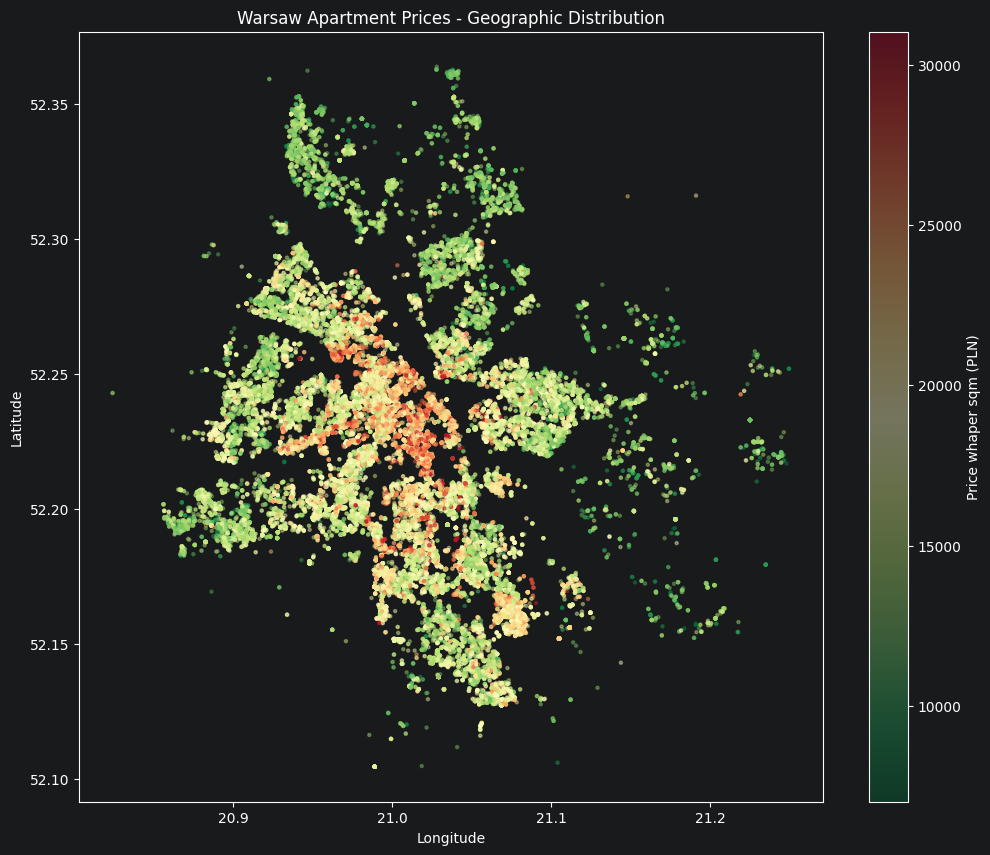

In [183]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['pricePerSqm'], cmap='RdYlGn_r',
    alpha=0.4, s=5
)
plt.colorbar(scatter, label='Price whaper sqm (PLN)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Warsaw Apartment Prices - Geographic Distribution')
plt.show()

## Preprocessing

In [184]:
df.drop(columns=['condition'], inplace=True) # 76% missing

distance_cols = ['schoolDistance', 'clinicDistance', 'postOfficeDistance',
                 'kindergartenDistance', 'restaurantDistance', 'collegeDistance', 'pharmacyDistance']
for col in distance_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"Rows before outlier removal: {len(df)}")
low = df['pricePerSqm'].quantile(0.01)
high = df['pricePerSqm'].quantile(0.99)
df = df[(df['pricePerSqm'] >= low) & (df['pricePerSqm'] <= high)].reset_index(drop=True)
print(f"Rows after outlier removal: {len(df)}")
print(f"pricePerSqm range: {df['pricePerSqm'].min():.0f} - {df['pricePerSqm'].max():.0f} PLN/sqm")

Rows before outlier removal: 59246
Rows after outlier removal: 58065
pricePerSqm range: 9598 - 28944 PLN/sqm


In [185]:
df.to_parquet('../data/processed/warsaw_apartments.parquet', index=False)
print(f"Saved {len(df)} rows, {df.shape[1]} columns to data/processed/warsaw_apartments.parquet")

Saved 58065 rows, 27 columns to data/processed/warsaw_apartments.parquet
